In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from itertools import product

In [2]:
df = pd.read_csv('Air Traffic Data Cor Updated.csv',parse_dates=['Date'],index_col='Date')
df.head()


,domestic passengers,international passenegrs,domestic freight(in tonne),international freight(in tonne),GDP (in dollars),Jet Fuel Price per Gallon,Inflation Rate,Unemployement Rate
Date,,,,,,,,
2009-01-01,3288004,885435,20832,11675,1.341888e+12,71.75,10.88,7.66
2009-02-01,3293220,757168,18645,12482,1.341888e+12,61.97,10.88,7.66
2009-03-01,3122400,848046,23046,15359,1.341888e+12,65.01,10.88,7.66
2009-04-01,3266686,861715,21623,14512,1.341888e+12,68.55,10.88,7.66
2009-05-01,3883887,898410,19534,14586,1.341888e+12,72.22,10.88,7.66


In [3]:
feature = df['domestic passengers']

--- Stationarity Test on Log-Differenced Data ---
ADF Statistic: -4.2072
p-value: 0.0006
Critical Values:
	1%: -3.4676
	5%: -2.8779
	10%: -2.5755

Result: The p-value is less than or equal to 0.05. The data is likely stationary. ✅


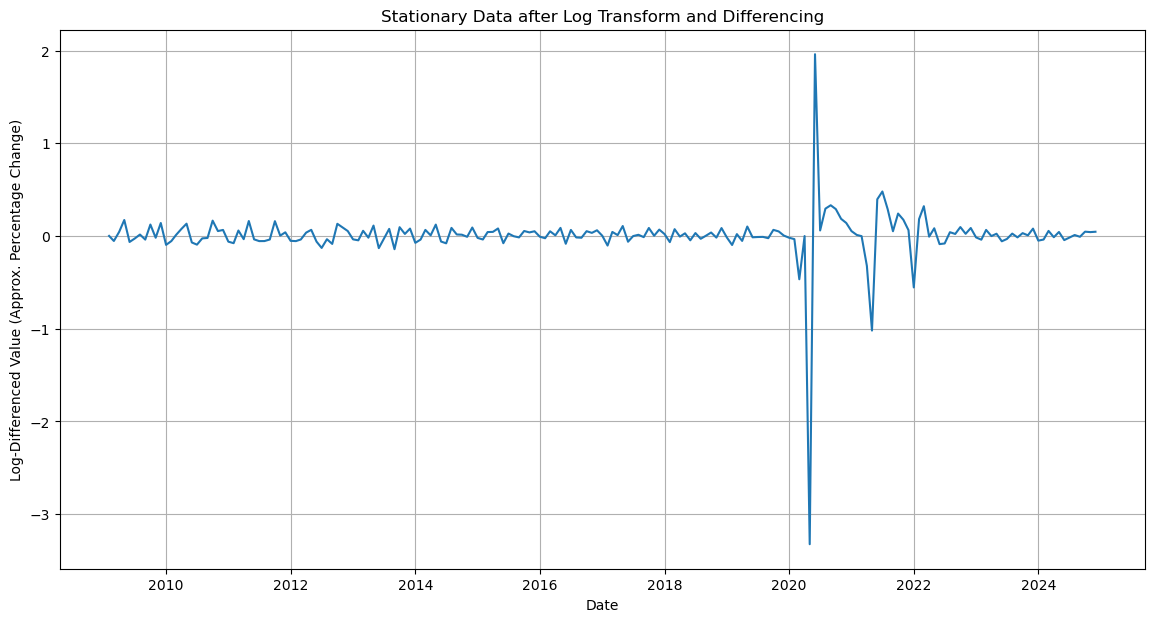

In [4]:
if (feature <= 0).any():
    print("Warning: Data contains non-positive values. Log transform cannot be applied directly.")
else:
    log_feature = np.log(feature)

    # --- 3. Apply First-Order Differencing ---
    log_diff_feature = log_feature.diff().dropna() # Use .dropna() to remove the first NaN value

    # --- 4. Test for Stationarity ---
    print("--- Stationarity Test on Log-Differenced Data ---")
    adf_test = adfuller(log_diff_feature)
    print(f'ADF Statistic: {adf_test[0]:.4f}')
    print(f'p-value: {adf_test[1]:.4f}')
    print('Critical Values:')
    for key, value in adf_test[4].items():
        print(f'\t{key}: {value:.4f}')

    if adf_test[1] <= 0.05:
        print("\nResult: The p-value is less than or equal to 0.05. The data is likely stationary. ✅")
    else:
        print("\nResult: The p-value is greater than 0.05. The data is likely non-stationary. ❌")


    # --- 5. Visualize the Transformed Data ---
    plt.figure(figsize=(14, 7))
    plt.plot(log_diff_feature)
    plt.title('Stationary Data after Log Transform and Differencing')
    plt.xlabel('Date')
    plt.ylabel('Log-Differenced Value (Approx. Percentage Change)')
    plt.grid(True)
    plt.show()

Applying on rest of the features

In [6]:
df_final = pd.DataFrame(index=df.index)
stationarity_results=[]

In [10]:
numerical_cols = df.select_dtypes(include=np.number).columns
numerical_cols = df[['domestic passengers', 'international passenegrs','domestic freight(in tonne)', 'international freight(in tonne)']]

In [12]:
for col in numerical_cols:
    print(f"Processing feature: {col}...")

    # --- If not skipped, apply log and differencing ---
    feature_series = df[col]
    
    if (feature_series <= 0).any():
        print(f"  -> Applying log(x+1) and differencing.")
        log_feature = np.log1p(feature_series)
    else:
        print(f"  -> Applying log and differencing.")
        log_feature = np.log(feature_series)
        
    log_diff_feature = log_feature.diff() # .dropna() is handled later by merging
    
    df_final[f'{col}_log_diff'] = log_diff_feature

# --- 4. Clean up the final DataFrame ---
# The first row will have NaNs from differencing, so we drop it
df_final.dropna(inplace=True)

# --- 5. Display the Head of the Final DataFrame ---
print("\n--- Head of the Final Processed DataFrame ---")
print(df_final.head())

Processing feature: domestic passengers...
  -> Applying log and differencing.
Processing feature: international passenegrs...
  -> Applying log and differencing.
Processing feature: domestic freight(in tonne)...
  -> Applying log and differencing.
Processing feature: international freight(in tonne)...
  -> Applying log and differencing.

--- Head of the Final Processed DataFrame ---
            domestic passengers_log_diff  international passenegrs_log_diff  \
Date                                                                          
2009-02-01                      0.001585                          -0.156494   
2009-03-01                     -0.053264                           0.113350   
2009-04-01                      0.045174                           0.015990   
2009-05-01                      0.173060                           0.041702   
2009-06-01                     -0.063824                           0.005875   

            domestic freight(in tonne)_log_diff  \
Date    

In [13]:
df_final.head()

,domestic passengers_log_diff,international passenegrs_log_diff,domestic freight(in tonne)_log_diff,international freight(in tonne)_log_diff
Date,,,,
2009-02-01,0.001585,-0.156494,-0.110912,0.066838
2009-03-01,-0.053264,0.113350,0.211914,0.207414
2009-04-01,0.045174,0.015990,-0.063735,-0.056726
2009-05-01,0.173060,0.041702,-0.101601,0.005086
2009-06-01,-0.063824,0.005875,0.149680,0.003217


In [14]:
def check_stationarity(timeseries):
    print("Results of ADF Test:")
    adf_test = adfuller(timeseries, autolag='AIC')
    df_output = pd.Series(adf_test[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in adf_test[4].items():
        df_output[f'Critical Value ({key})'] = value
    print(df_output)
    
    if adf_test[1] <= 0.05:
        print("Conclusion: The series is stationary.")
    else:
        print("Conclusion: The series is NOT stationary. Differencing may be needed.")

In [15]:
col = df_final.columns.to_list()
col = col[1:]
for i in col:
    print(f"\nFeature Name : {i}")
    check_stationarity(df_final[i])


Feature Name : international passenegrs_log_diff
Results of ADF Test:
Test Statistic                -1.067548e+01
p-value                        4.064401e-19
#Lags Used                     2.000000e+00
Number of Observations Used    1.880000e+02
Critical Value (1%)           -3.465620e+00
Critical Value (5%)           -2.877040e+00
Critical Value (10%)          -2.575032e+00
dtype: float64
Conclusion: The series is stationary.

Feature Name : domestic freight(in tonne)_log_diff
Results of ADF Test:
Test Statistic                  -4.317141
p-value                          0.000415
#Lags Used                      13.000000
Number of Observations Used    177.000000
Critical Value (1%)             -3.467845
Critical Value (5%)             -2.878012
Critical Value (10%)            -2.575551
dtype: float64
Conclusion: The series is stationary.

Feature Name : international freight(in tonne)_log_diff
Results of ADF Test:
Test Statistic                -1.155962e+01
p-value                   

In [ ]:
df_final = df_final

In [11]:
df_final.to_csv('Air Traffic Data Stationary.csv',index=True)